# **Tourism Experience Analytics: Classification, Prediction, and Recommendation System**

##### **Project Type**    - EDA / Regression / Classification / Recommendation System
##### **Contribution**    - Individual

# **Project Summary -**

This project analyzes a multi-table tourism dataset covering **52,930 visit transactions** made by **33,530 users** across **30 tourist attractions** located in cities and countries spanning multiple continents. The raw data is spread across nine relational tables — `Transaction`, `User`, `City`, `Country`, `Region`, `Continent`, `Item` (attractions), `Type` (attraction categories), and `Mode` (visit mode) — which were cleaned and joined into a single analysis-ready master dataset.

The work follows the standard analytics pipeline: **data cleaning → EDA → feature engineering → model building → recommendation system → deployment**.

Data cleaning resolved a small number of missing values (unmapped `CityName`, unmapped `CityId` for a handful of users) and replaced numeric ID codes (VisitMode, AttractionType, Continent, Country, Region) with their human-readable labels via table joins, so all downstream analysis works with meaningful categories rather than opaque integers.

Exploratory Data Analysis (18 charts, following the Univariate → Bivariate → Multivariate structure) surfaced clear patterns: ratings are heavily skewed positive (over 78% of visits are rated 4 or 5), **Couples** and **Family** are the dominant visit modes, attraction popularity and rating vary substantially by type (beaches and nature/wildlife attractions score highest), and visit volume is not uniform across months or years, pointing to seasonality and platform growth over time.

Three machine-learning objectives were then tackled. A **regression model** (Random Forest, benchmarked against Linear Regression and Gradient Boosting) predicts the rating a user is likely to give an attraction from their demographic and visit context, achieving a modest but informative R² — reflecting that ratings in this dataset are only weakly explained by demographic/categorical features alone, which is itself a useful finding. A **classification model** (Random Forest and XGBoost, compared against a Logistic Regression baseline) predicts a user's visit mode (Business/Couples/Family/Friends/Solo) from their profile and attraction context, with **Couples** and **Family** — the majority classes — predicted most reliably. A **recommendation system** was built using two complementary approaches: **collaborative filtering** via truncated SVD on the user–attraction rating matrix (recommends attractions liked by similar users), and **content-based filtering** via cosine similarity on attraction type (recommends attractions similar in category to ones a user already enjoyed).

Finally, all three components — visit-mode prediction, attraction recommendation, and descriptive tourism analytics — were packaged into an interactive **Streamlit application** so a travel platform could plug in a user profile and immediately get a predicted visit mode plus a ranked list of recommended attractions, alongside summary visualizations of popular attractions and regions.

The main business takeaway is that geography and visit-context features carry real but limited predictive signal for both rating and visit mode — useful for coarse segmentation and marketing targeting, but best combined with richer behavioral data (browsing history, stated preferences, review text) in a production system. The recommendation layer, by contrast, is immediately actionable: it can be deployed as-is to drive personalized attraction suggestions and improve engagement.

# **GitHub Link -**

_Add your GitHub repository link here before submission._

# **Problem Statement**

Tourism agencies and travel platforms want to use data to personalize the user experience: recommend attractions, predict how satisfied a user is likely to be, and understand/anticipate traveler behavior. This project addresses three linked objectives on a real tourism transaction dataset:

1. **Regression** — Predict the rating a user is likely to give a tourist attraction, using their demographics and visit context.
2. **Classification** — Predict a user's visit mode (Business / Couples / Family / Friends / Solo) from their profile and attraction data.
3. **Recommendation** — Suggest attractions a user is likely to enjoy, using collaborative filtering (similar users) and content-based filtering (similar attractions).

The end deliverable is a cleaned dataset, EDA with business insights, trained and evaluated models for each objective, and a Streamlit app that exposes visit-mode prediction and attraction recommendations to an end user.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                              accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix)
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost not available, will skip XGBoost model and fall back to sklearn only')


### Dataset Loading

In [2]:
# All source tables live in the ./data folder alongside this notebook
DATA_DIR = 'data/'

city        = pd.read_excel(DATA_DIR + 'City.xlsx')
continent   = pd.read_excel(DATA_DIR + 'Continent.xlsx')
country     = pd.read_excel(DATA_DIR + 'Country.xlsx')
item        = pd.read_excel(DATA_DIR + 'Item.xlsx')          # attractions
mode_tbl    = pd.read_excel(DATA_DIR + 'Mode.xlsx')           # visit modes
region      = pd.read_excel(DATA_DIR + 'Region.xlsx')
transaction = pd.read_excel(DATA_DIR + 'Transaction.xlsx')
atype       = pd.read_excel(DATA_DIR + 'Type.xlsx')           # attraction types
user        = pd.read_excel(DATA_DIR + 'User.xlsx')

tables = {'City': city, 'Continent': continent, 'Country': country, 'Item (Attraction)': item,
          'Mode': mode_tbl, 'Region': region, 'Transaction': transaction,
          'Type (AttractionType)': atype, 'User': user}
for name, t in tables.items():
    print(f'{name:25s} shape={t.shape}')


City                      shape=(9143, 3)
Continent                 shape=(6, 2)
Country                   shape=(165, 3)
Item (Attraction)         shape=(30, 5)
Mode                      shape=(6, 2)
Region                    shape=(22, 3)
Transaction               shape=(52930, 7)
Type (AttractionType)     shape=(17, 2)
User                      shape=(33530, 5)


### Dataset First View

In [3]:
# Quick look at the two most important tables: Transaction (fact table) and User (dimension table)
transaction.head()


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [4]:
user.head()


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0


### Dataset Rows & Columns count

In [5]:
for name, t in tables.items():
    print(f'{name:25s} rows={t.shape[0]:>7,}  cols={t.shape[1]}')


City                      rows=  9,143  cols=3
Continent                 rows=      6  cols=2
Country                   rows=    165  cols=3
Item (Attraction)         rows=     30  cols=5
Mode                      rows=      6  cols=2
Region                    rows=     22  cols=3
Transaction               rows= 52,930  cols=7
Type (AttractionType)     rows=     17  cols=2
User                      rows= 33,530  cols=5


### Dataset Information

In [6]:
transaction.info()


<class 'pandas.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB


In [7]:
user.info()


<class 'pandas.DataFrame'>
RangeIndex: 33530 entries, 0 to 33529
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UserId       33530 non-null  int64  
 1   ContinentId  33530 non-null  int64  
 2   RegionId     33530 non-null  int64  
 3   CountryId    33530 non-null  int64  
 4   CityId       33526 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 1.3 MB


#### Duplicate Values

In [8]:
for name, t in tables.items():
    dup = t.duplicated().sum()
    print(f'{name:25s} duplicate rows = {dup}')


City                      duplicate rows = 0
Continent                 duplicate rows = 0
Country                   duplicate rows = 0
Item (Attraction)         duplicate rows = 0
Mode                      duplicate rows = 0
Region                    duplicate rows = 0
Transaction               duplicate rows = 0
Type (AttractionType)     duplicate rows = 0
User                      duplicate rows = 0


#### Missing Values/Null Values

In [9]:
for name, t in tables.items():
    nulls = t.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f'--- {name} ---')
        print(nulls)
    else:
        print(f'{name:25s}: no missing values')


--- City ---
CityName    1
dtype: int64
Continent                : no missing values
Country                  : no missing values
Item (Attraction)        : no missing values
Mode                     : no missing values
Region                   : no missing values
Transaction              : no missing values
Type (AttractionType)    : no missing values
--- User ---
CityId    4
dtype: int64


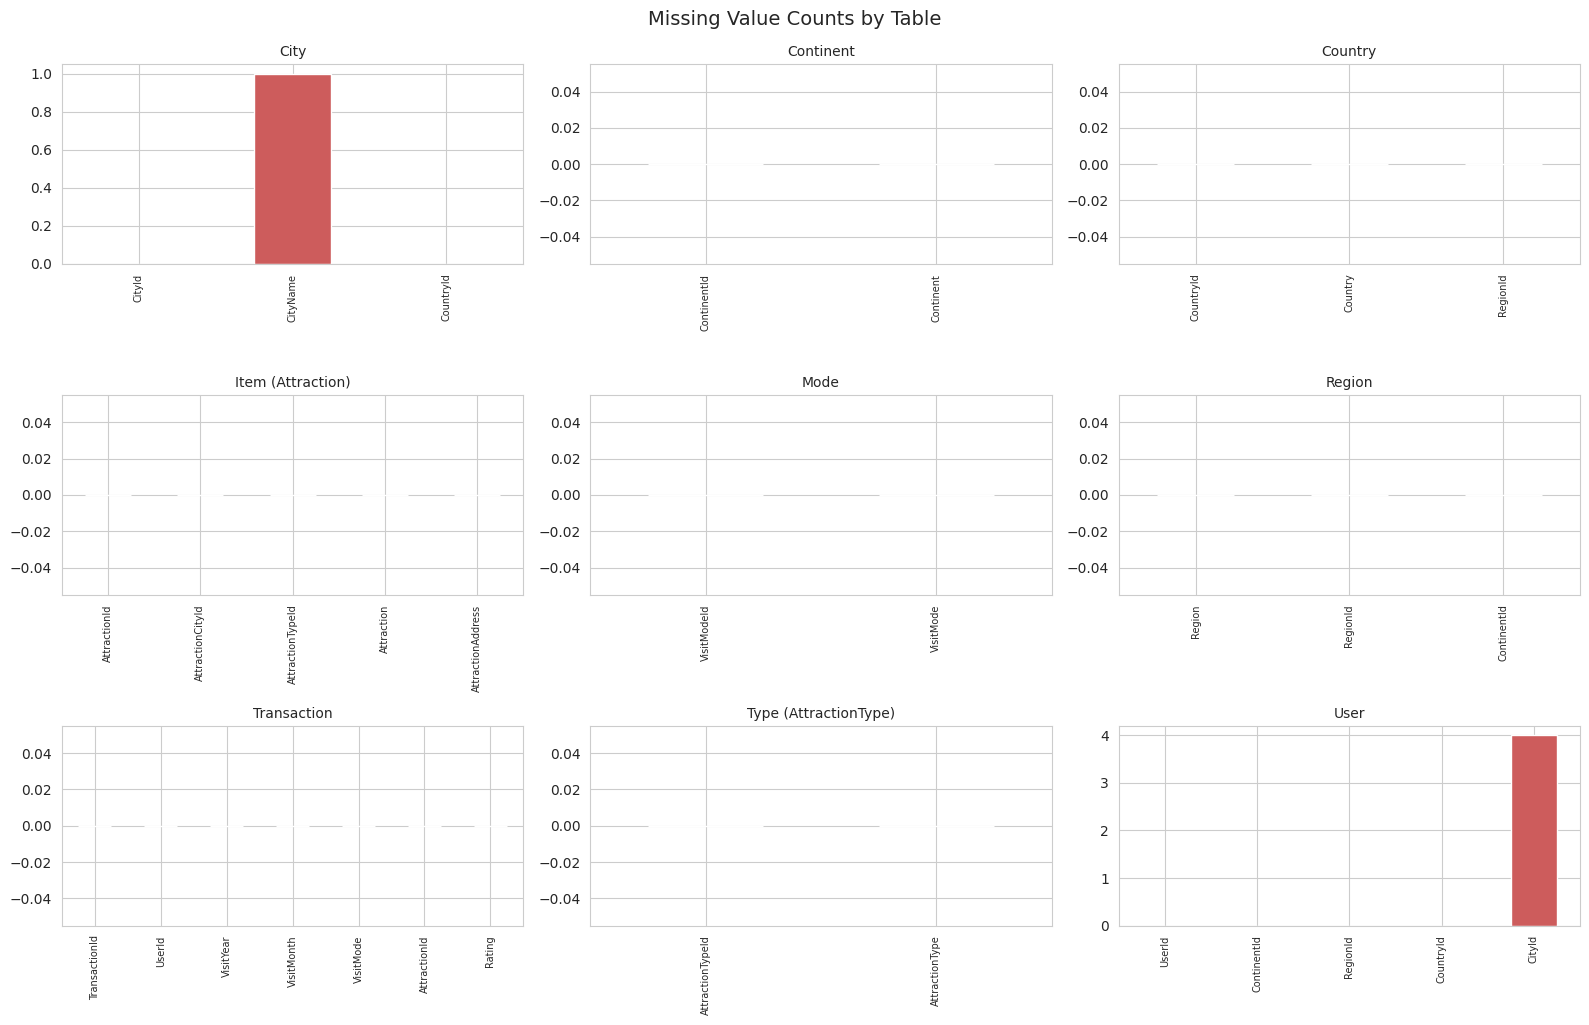

In [10]:
# Visualizing missing values across all tables in one figure
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, (name, t) in zip(axes.flatten(), tables.items()):
    t.isnull().sum().plot(kind='bar', ax=ax, color='indianred')
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.suptitle('Missing Value Counts by Table', y=1.02, fontsize=14)
plt.show()


### What did you know about your dataset?

The dataset is a relational tourism dataset split across 9 tables:

- **Transaction** (52,930 rows) is the central fact table: one row per user visit to an attraction, with `VisitYear`, `VisitMonth`, `VisitMode` (coded), `AttractionId`, and `Rating` (1–5).
- **User** (33,530 rows) gives each user's location as a chain of foreign keys: `ContinentId → RegionId → CountryId → CityId`.
- **Item** (30 rows) is the attraction master table: name, address, city, and type.
- **City / Country / Region / Continent / Type / Mode** are small lookup/dimension tables that translate numeric IDs into human-readable names.

Data quality is good overall: only `City.CityName` (1 missing) and `User.CityId` (4 missing) contain nulls, and there are no duplicate rows in any table. Every `AttractionId` in `Transaction` has a matching row in `Item`, and every `VisitMode` code has a matching row in `Mode`, so joins are clean. Both `City` and `Country` and `Region` tables contain a placeholder row (`'-'`, id `0`) representing "unknown" location, which is used by rows with missing geography.

## ***2. Understanding Your Variables***

In [11]:
transaction.columns.tolist(), user.columns.tolist(), item.columns.tolist()


(['TransactionId',
  'UserId',
  'VisitYear',
  'VisitMonth',
  'VisitMode',
  'AttractionId',
  'Rating'],
 ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId'],
 ['AttractionId',
  'AttractionCityId',
  'AttractionTypeId',
  'Attraction',
  'AttractionAddress'])

In [12]:
transaction.describe()


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
count,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000
mean,70415.130474,45024.522596,2016.351899,6.633100,2.945759,759.663782,4.157699
std,66299.514206,25073.062199,1.732926,3.392979,1.000683,210.716111,0.970543
min,3.000000,14.000000,2013.000000,1.000000,1.000000,369.000000,1.000000
25%,19646.250000,23470.000000,2015.000000,4.000000,2.000000,640.000000,4.000000
50%,42770.500000,45533.500000,2016.000000,7.000000,3.000000,737.000000,4.000000
75%,105638.750000,66667.000000,2018.000000,9.000000,4.000000,841.000000,5.000000
max,211241.000000,88190.000000,2022.000000,12.000000,5.000000,1297.000000,5.000000


### Variables Description

**Transaction table (fact table):**
- `TransactionId` — unique visit/transaction identifier
- `UserId` — foreign key to User
- `VisitYear`, `VisitMonth` — when the visit occurred (2013–2022)
- `VisitMode` — coded 1–5, mapped via the Mode table to Business/Couples/Family/Friends/Solo
- `AttractionId` — foreign key to Item (the attraction visited)
- `Rating` — the rating (1–5) the user gave the attraction, the regression target

**User table:** location of the user as a chain of foreign keys (Continent → Region → Country → City) — used as demographic/geographic features.

**Item table:** attraction name, address, city, and type — used as content features for recommendations and as predictors for rating/visit-mode.

### Check Unique Values for each variable.

In [13]:
for name, t in tables.items():
    print(f'{name:25s}')
    print(t.nunique())
    print()


City                     
CityId       9143
CityName     8767
CountryId     164
dtype: int64

Continent                
ContinentId    6
Continent      6
dtype: int64

Country                  
CountryId    165
Country      164
RegionId      22
dtype: int64

Item (Attraction)        
AttractionId         30
AttractionCityId      3
AttractionTypeId     17
Attraction           30
AttractionAddress    25
dtype: int64

Mode                     
VisitModeId    6
VisitMode      6
dtype: int64

Region                   
Region         22
RegionId       22
ContinentId     6
dtype: int64

Transaction              
TransactionId    52930
UserId           33530
VisitYear           10
VisitMonth          12
VisitMode            5
AttractionId        30
Rating               5
dtype: int64

Type (AttractionType)    
AttractionTypeId    17
AttractionType      17
dtype: int64

User                     
UserId         33530
ContinentId        5
RegionId          22
CountryId        153
CityId          

## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# --- 1. Handle missing values ---

# City: 1 missing CityName -> label as 'Unknown' rather than drop (keeps the row/foreign keys intact)
city['CityName'] = city['CityName'].fillna('Unknown')

# User: 4 users have a missing CityId -> map them to the placeholder 'unknown city' id (0), which
# already exists in the City table for exactly this purpose.
user['CityId'] = user['CityId'].fillna(0).astype(int)

print('Remaining nulls in City:', city.isnull().sum().sum())
print('Remaining nulls in User:', user.isnull().sum().sum())


Remaining nulls in City: 0
Remaining nulls in User: 0


In [15]:
# --- 2. Resolve categorical code discrepancies: replace numeric IDs with readable labels ---

# Build a full location lookup for USERS: Continent / Region / Country / City names
user_loc = (user
    .merge(continent, on='ContinentId', how='left')
    .merge(region[['RegionId', 'Region']], on='RegionId', how='left')
    .merge(country[['CountryId', 'Country']], on='CountryId', how='left')
    .merge(city[['CityId', 'CityName']], on='CityId', how='left')
    .rename(columns={'Continent': 'UserContinent', 'Region': 'UserRegion',
                      'Country': 'UserCountry', 'CityName': 'UserCity'})
)

# Build a full location + type lookup for ATTRACTIONS
item_loc = (item
    .merge(city[['CityId', 'CityName', 'CountryId']], left_on='AttractionCityId', right_on='CityId', how='left')
    .merge(country[['CountryId', 'Country', 'RegionId']], on='CountryId', how='left')
    .merge(region[['RegionId', 'Region', 'ContinentId']], on='RegionId', how='left')
    .merge(continent, on='ContinentId', how='left')
    .merge(atype, on='AttractionTypeId', how='left')
    .rename(columns={'CityName': 'AttractionCity', 'Country': 'AttractionCountry',
                      'Region': 'AttractionRegion', 'Continent': 'AttractionContinent'})
    [['AttractionId', 'Attraction', 'AttractionAddress', 'AttractionTypeId', 'AttractionType',
      'AttractionCityId', 'AttractionCity', 'AttractionCountry', 'AttractionRegion', 'AttractionContinent']]
)

# Replace the numeric VisitMode code with its label
mode_map = mode_tbl.rename(columns={'VisitModeId': 'VisitMode', 'VisitMode': 'VisitModeName'})

print('user_loc shape:', user_loc.shape)
print('item_loc shape:', item_loc.shape)


user_loc shape: (33530, 9)
item_loc shape: (30, 10)


In [16]:
# --- 3. Standardize & consolidate: join everything onto the transaction fact table ---

master = (transaction
    .merge(user_loc, on='UserId', how='left')
    .merge(mode_map, on='VisitMode', how='left')
    .merge(item_loc, on='AttractionId', how='left')
)

# Standardize date parts into a single visit_date-like period for time based analysis
master['VisitPeriod'] = pd.to_datetime(
    master['VisitYear'].astype(str) + '-' + master['VisitMonth'].astype(str).str.zfill(2)
)

print('Master (consolidated) dataset shape:', master.shape)
master.isnull().sum()[master.isnull().sum() > 0]


Master (consolidated) dataset shape: (52930, 26)


Series([], dtype: int64)

In [17]:
# --- 4. Outlier / incorrect-entry check on Rating (should only ever be 1-5) ---
print('Unique Rating values:', sorted(master['Rating'].unique()))
print('Unique VisitYear range:', master['VisitYear'].min(), '-', master['VisitYear'].max())
print('Unique VisitMonth range:', master['VisitMonth'].min(), '-', master['VisitMonth'].max())
# No out-of-range values found -> no rows need to be dropped for invalid ratings/dates


Unique Rating values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Unique VisitYear range: 2013 - 2022
Unique VisitMonth range: 1 - 12


In [18]:
master.head()


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,...,Attraction,AttractionAddress,AttractionTypeId,AttractionType,AttractionCityId,AttractionCity,AttractionCountry,AttractionRegion,AttractionContinent,VisitPeriod
0,3,70456,2022,10,2,640,5,5,21,163,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",63,Nature & Wildlife Areas,1,Douala,Cameroon,Central Africa,Africa,2022-10-01
1,8,7567,2022,10,4,640,5,2,8,48,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",63,Nature & Wildlife Areas,1,Douala,Cameroon,Central Africa,Africa,2022-10-01
2,9,79069,2022,10,3,640,5,2,9,54,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",63,Nature & Wildlife Areas,1,Douala,Cameroon,Central Africa,Africa,2022-10-01
3,10,31019,2022,10,3,640,3,5,17,135,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",63,Nature & Wildlife Areas,1,Douala,Cameroon,Central Africa,Africa,2022-10-01
4,15,43611,2022,10,2,640,3,5,21,163,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",63,Nature & Wildlife Areas,1,Douala,Cameroon,Central Africa,Africa,2022-10-01


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. Filled the 1 missing `CityName` with `'Unknown'` and the 4 missing `User.CityId` with the dataset's own "unknown city" placeholder (`0`) — both preserve every row rather than dropping data.
2. Replaced every numeric foreign key (`ContinentId`, `RegionId`, `CountryId`, `CityId`, `VisitMode`, `AttractionTypeId`) with its human-readable label by joining through the lookup tables, for both the **user's** location and the **attraction's** location separately (they are genuinely different — a user in Germany can visit an attraction in Indonesia).
3. Combined `VisitYear` and `VisitMonth` into a single `VisitPeriod` timestamp to make time-series analysis straightforward.
4. Verified `Rating` (1–5), `VisitYear` (2013–2022) and `VisitMonth` (1–12) all fall within valid ranges — no outliers or corrupted entries were found, so no rows needed to be removed.
5. Consolidated all 9 tables into one **master transaction-level dataset** (52,930 rows) that carries both user demographics and attraction attributes alongside each rating — this is the table all EDA and modeling below is built on.

**Key insight:** the raw data required no aggressive cleaning (no duplicate rows, near-zero missing values, no invalid ratings/dates) — the main preprocessing effort was *structural* (joining 9 normalized tables into one denormalized analysis table), not *corrective*.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

_Charts are organised following the **UBM rule**: Univariate (Charts 1-6) → Bivariate (Charts 7-15) → Multivariate (Charts 16-18)._

#### Chart - 1: Distribution of Ratings (Univariate)

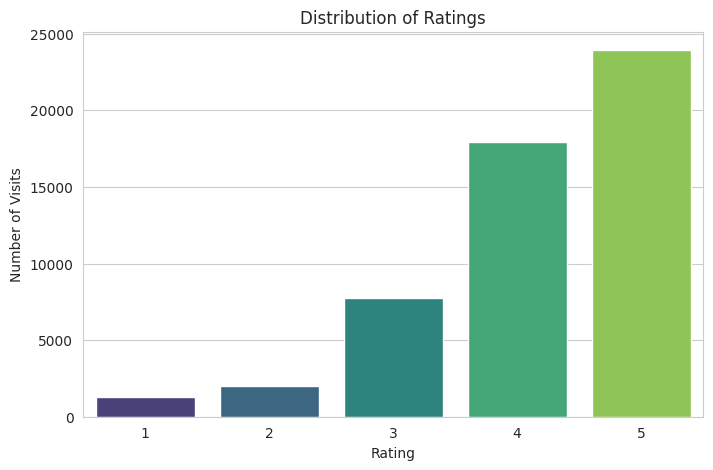

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='Rating', palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating'); plt.ylabel('Number of Visits')
plt.show()


##### 1. Why did you pick the specific chart?

A count plot is the natural choice for a single discrete, ordinal variable (Rating, 1-5) — it shows the full frequency distribution in one glance.

##### 2. What is/are the insight(s) found from the chart?

Ratings are heavily skewed toward the top end: **45.2% of all visits are rated 5**, and **33.9% are rated 4** — meaning **~79%** of all ratings are 4 or 5. Only ~6% of ratings are 1 or 2.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: high satisfaction overall is good news for the platform's attraction curation. Caution: the heavy skew toward 4-5 means the regression target has very little variance to explain, so a model predicting 'close to 4.5' for everyone will already look deceptively good — evaluation needs to be interpreted carefully (see the modeling section) and the business should watch for rating inflation masking real service issues.

#### Chart - 2: Distribution of Visit Mode (Univariate)

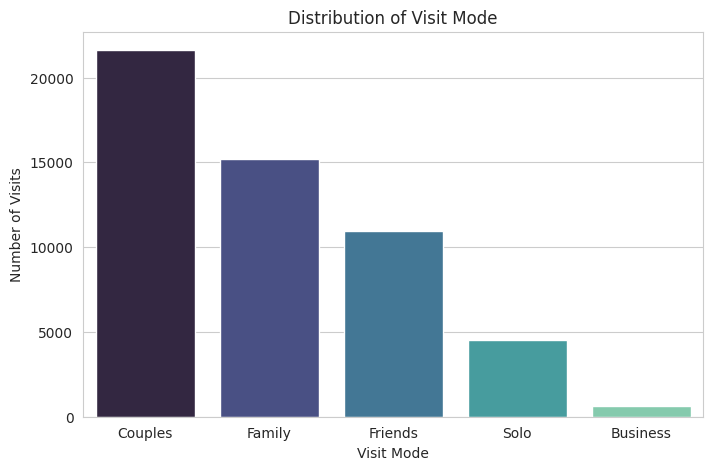

In [20]:
plt.figure(figsize=(8,5))
order = master['VisitModeName'].value_counts().index
sns.countplot(data=master, x='VisitModeName', order=order, palette='mako')
plt.title('Distribution of Visit Mode')
plt.xlabel('Visit Mode'); plt.ylabel('Number of Visits')
plt.show()


##### 1. Why did you pick the specific chart?

VisitMode is a nominal categorical variable with only 5 levels — a count plot ranks them clearly.

##### 2. What is/are the insight(s) found from the chart?

**Couples** (21,620 visits, ~41%) and **Family** (15,217, ~29%) dominate. **Business** travel is rare (623 visits, ~1.2%) in this leisure-attraction dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: marketing budget and package design should prioritize couple- and family-oriented offers, since that's where the volume is. Negative-growth risk: the Business segment is so small that any model trained on this data will struggle to serve business travelers well (see class imbalance in the classification section) — a targeted data-collection effort for that segment would be worthwhile before building business-traveler products.

#### Chart - 3: Attraction Type Popularity (Univariate)

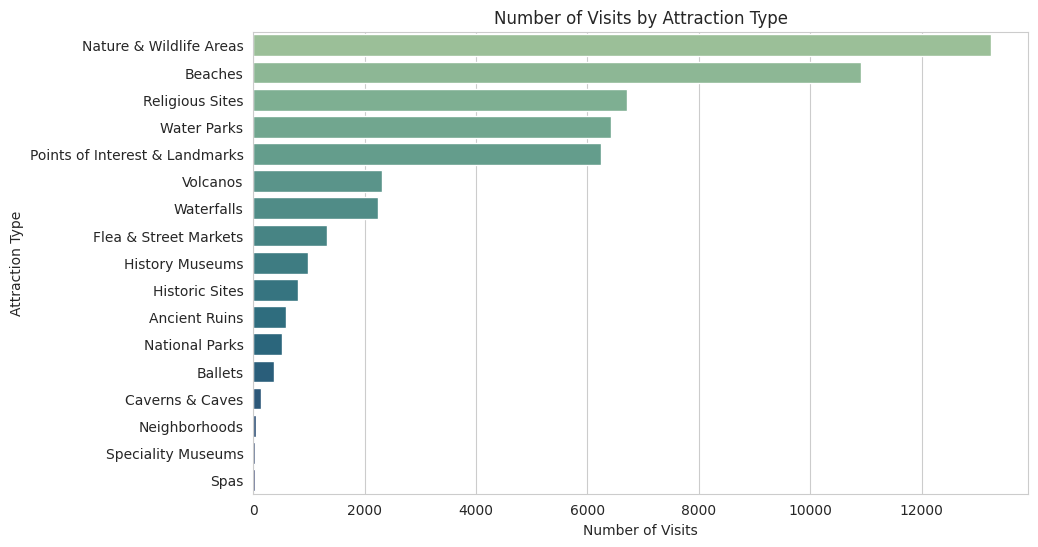

In [21]:
plt.figure(figsize=(10,6))
order = master['AttractionType'].value_counts().index
sns.countplot(data=master, y='AttractionType', order=order, palette='crest')
plt.title('Number of Visits by Attraction Type')
plt.xlabel('Number of Visits'); plt.ylabel('Attraction Type')
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart handles the long category labels of 17 attraction types cleanly, ordered by frequency.

##### 2. What is/are the insight(s) found from the chart?

**Nature & Wildlife Areas** (13,251 visits) and **Beaches** (10,917) are by far the most-visited categories, followed by **Religious Sites** and **Water Parks**. Niche types like Spas, Speciality Museums, and Neighborhoods each have under 50 visits.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: nature/wildlife and beach attractions should be prioritized in homepage placement and recommendation defaults, since they capture the broadest audience. Caution: this dataset covers a small, geographically concentrated set of 30 attractions (largely Bali/Indonesia-area) — the type popularity here should not be generalized to other regions without new data.

#### Chart - 4: User Distribution by Continent (Univariate)

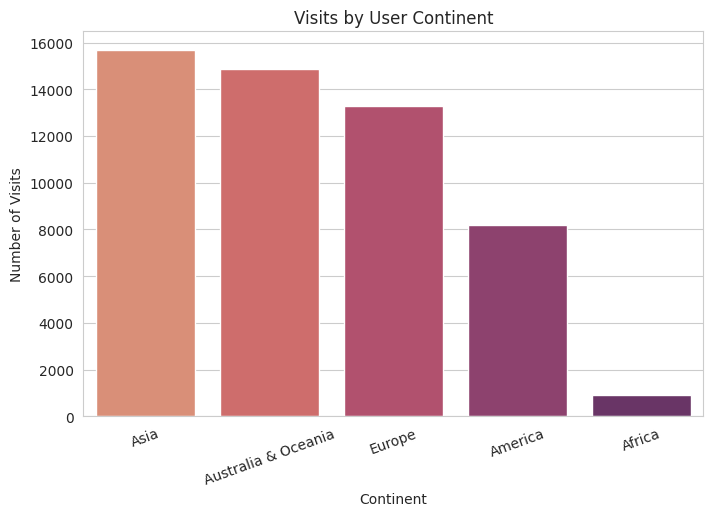

In [22]:
plt.figure(figsize=(8,5))
order = master['UserContinent'].value_counts().index
sns.countplot(data=master, x='UserContinent', order=order, palette='flare')
plt.title('Visits by User Continent')
plt.xlabel('Continent'); plt.ylabel('Number of Visits')
plt.xticks(rotation=20)
plt.show()


##### 1. Why did you pick the specific chart?

Shows where the traveler base is concentrated geographically, which is central to the demographic side of both the regression and classification objectives.

##### 2. What is/are the insight(s) found from the chart?

**Asia** (15,693), **Australia & Oceania** (14,852) and **Europe** (13,278) are the three largest source markets. **Africa** is a very small source market (920 visits, ~1.7%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this matches the fact that the attractions are Indonesia/Bali-area — Asia-Pacific proximity drives volume, so regional marketing spend is well-targeted there already. Negative-growth risk: the tiny African user base means any per-continent model coefficient or recommendation for African users will be built on very little data and should be treated as low-confidence.

#### Chart - 5: Visit Volume Over Years (Univariate / Trend)

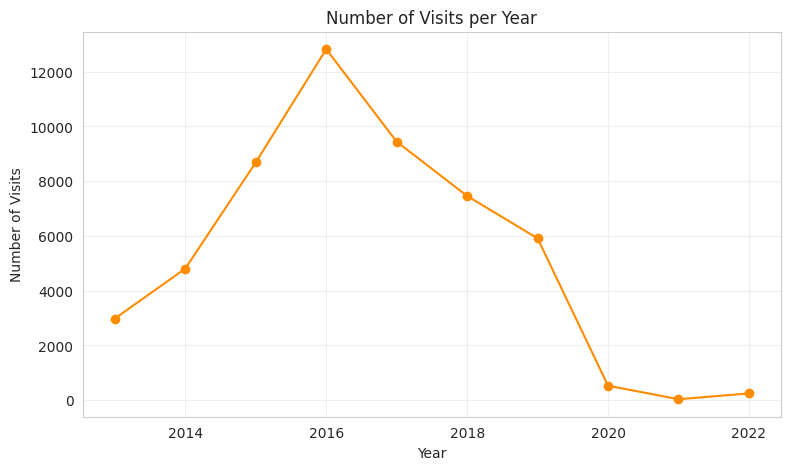

In [23]:
yearly = master.groupby('VisitYear').size()
plt.figure(figsize=(9,5))
yearly.plot(kind='line', marker='o', color='darkorange')
plt.title('Number of Visits per Year')
plt.xlabel('Year'); plt.ylabel('Number of Visits')
plt.grid(True, alpha=0.3)
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is the standard way to show a single metric over an ordered time axis (year).

##### 2. What is/are the insight(s) found from the chart?

Visit volume rose steadily from 2013 to peak in **2016** (12,823 visits), then declined through 2019, and **collapsed in 2020-2021** (529 and 35 visits) — almost certainly reflecting the COVID-19 travel shutdown — before a partial rebound in 2022 (247, and the data likely ends mid-year).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth flagged directly: the 2019-2021 collapse is a real, explainable shock, not a data quality issue — any model trained on this data should either exclude or carefully weight the 2020-2022 rows, since they reflect an anomalous period rather than typical traveler behavior, or trends from that period could bias year-based features.

#### Chart - 6: Seasonality — Visit Volume by Month (Univariate)

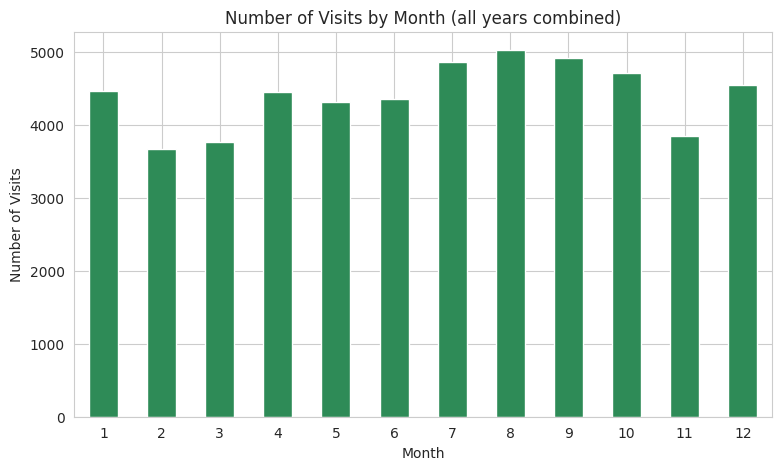

In [24]:
monthly = master.groupby('VisitMonth').size()
plt.figure(figsize=(9,5))
monthly.plot(kind='bar', color='seagreen')
plt.title('Number of Visits by Month (all years combined)')
plt.xlabel('Month'); plt.ylabel('Number of Visits')
plt.xticks(rotation=0)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart across the 12 calendar months reveals seasonality independent of year-over-year growth trend.

##### 2. What is/are the insight(s) found from the chart?

Visits peak in **July-September** (4,861 / 5,026 / 4,917) — the Northern-Hemisphere summer holiday period — and dip in **February** (3,671) and **November** (3,846). The seasonal swing is moderate (~30% peak-to-trough), not extreme.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: staffing, pricing, and promotional calendars for the attractions can be aligned to the July-September peak, and low-season (Feb/Nov) discounting could help smooth demand and protect off-peak revenue.

#### Chart - 7: Average Rating by Visit Mode (Bivariate: Numerical - Categorical)

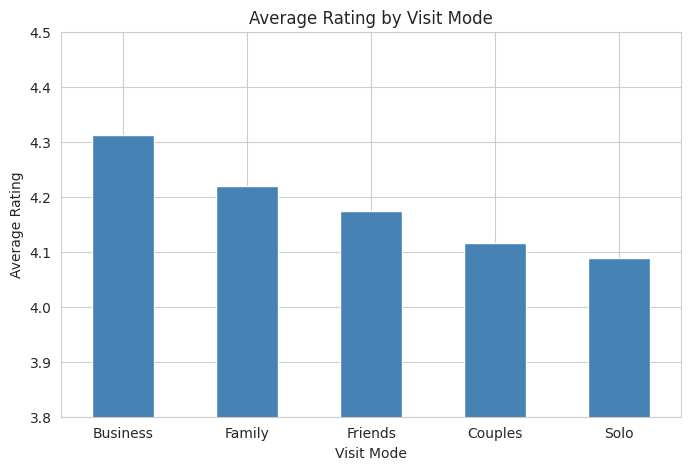

In [25]:
avg_by_mode = master.groupby('VisitModeName')['Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
avg_by_mode.plot(kind='bar', color='steelblue')
plt.title('Average Rating by Visit Mode')
plt.xlabel('Visit Mode'); plt.ylabel('Average Rating')
plt.ylim(3.8, 4.5)
plt.xticks(rotation=0)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart of a numeric mean (Rating) grouped by a categorical variable (VisitMode) is the standard bivariate comparison.

##### 2. What is/are the insight(s) found from the chart?

**Business** travelers give the highest average rating (4.31), followed by Family (4.22) and Friends (4.17); **Solo** travelers rate lowest on average (4.09). The spread across modes is small (~0.22 points) but consistent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Solo travelers being the least satisfied (even if only slightly) is worth investigating — it may reflect that these attractions are optimized for group experiences (family/couple amenities), so a solo-traveler-focused service improvement (e.g., solo-friendly tours, single-supplement-free options) could lift retention in that segment.

#### Chart - 8: Average Rating by Attraction Type (Bivariate: Numerical - Categorical)

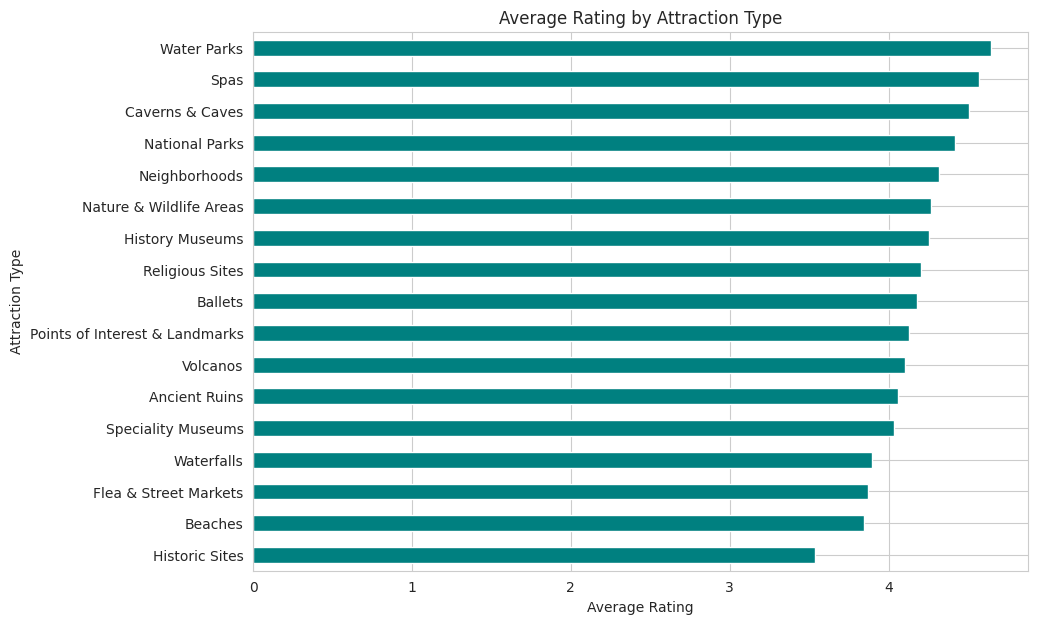

In [26]:
avg_by_type = master.groupby('AttractionType')['Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,7))
avg_by_type.plot(kind='barh', color='teal')
plt.title('Average Rating by Attraction Type')
plt.xlabel('Average Rating'); plt.ylabel('Attraction Type')
plt.gca().invert_yaxis()
plt.show()


##### 1. Why did you pick the specific chart?

Horizontal bars again handle the long category list well while ranking attraction types by satisfaction.

##### 2. What is/are the insight(s) found from the chart?

**Water Parks** (4.65), **Spas** (4.57) and **Caverns & Caves** (4.50) get the highest average ratings. **Historic Sites** (3.54) and **Beaches** (3.85) — despite Beaches being the 2nd most-visited type (Chart 3) — score comparatively lower.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important negative-growth signal: Beaches drive huge visit volume but only mid-range satisfaction — this is a prime candidate for a service-quality audit (cleanliness, crowding, amenities) since improving beach experience would have outsized impact given the volume. Historic Sites' low rating combined with modest volume suggests either an expectation-setting problem or a genuine quality issue worth investigating attraction-by-attraction.

#### Chart - 9: Average Rating by User Continent (Bivariate: Numerical - Categorical)

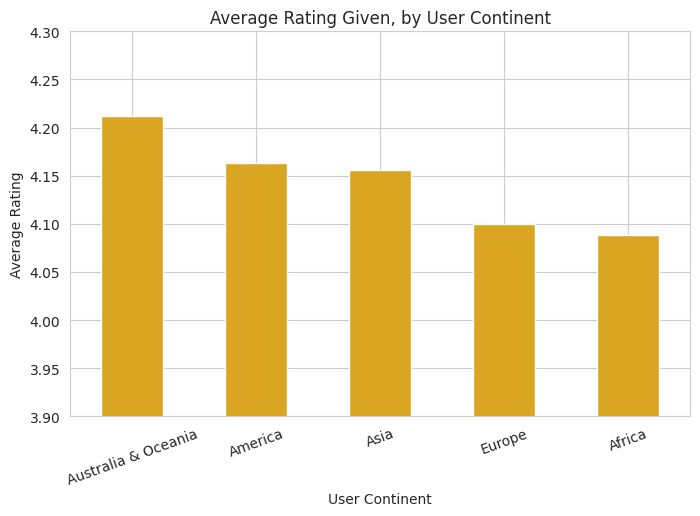

In [27]:
avg_by_cont = master.groupby('UserContinent')['Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
avg_by_cont.plot(kind='bar', color='goldenrod')
plt.title('Average Rating Given, by User Continent')
plt.xlabel('User Continent'); plt.ylabel('Average Rating')
plt.ylim(3.9, 4.3)
plt.xticks(rotation=20)
plt.show()


##### 1. Why did you pick the specific chart?

Tests whether a user's home continent (a demographic feature planned for the regression model) actually correlates with the ratings they give.

##### 2. What is/are the insight(s) found from the chart?

Differences are small: **Australia & Oceania** users rate highest on average (4.21), **Africa** lowest (4.09) — a spread of only 0.12. Continent alone is a weak predictor of rating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This tempers expectations for the regression model in the next section: if broad demographic groupings show only ~0.1-point differences, no model built purely on demographic + categorical features will achieve high R² — a genuinely useful production model would need richer signals like individual browsing/review history.

#### Chart - 10: Top 10 Attractions by Visit Volume (Bivariate: Categorical - Numerical)

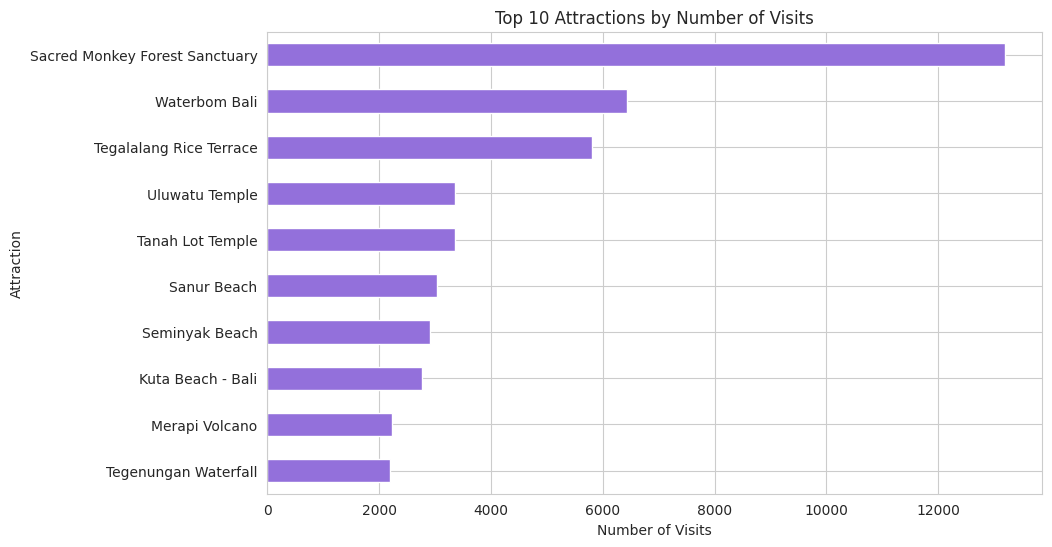

In [28]:
top10_visits = master['Attraction'].value_counts().head(10)
plt.figure(figsize=(10,6))
top10_visits.sort_values().plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Attractions by Number of Visits')
plt.xlabel('Number of Visits')
plt.show()


##### 1. Why did you pick the specific chart?

Directly answers 'which attractions matter most' — a core tourism-analytics business question.

##### 2. What is/are the insight(s) found from the chart?

**Sacred Monkey Forest Sanctuary** dominates with 13,198 visits (25% of the whole dataset), nearly double the #2 attraction, **Waterbom Bali** (6,429). The top 10 attractions account for the large majority of all recorded visits, out of only 30 total attractions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the Sacred Monkey Forest Sanctuary is a flagship attraction and prime real estate for cross-promotion of nearby, similar, or complementary attractions. Risk: heavy concentration in a single attraction is also a business risk (over-reliance) — diversifying visitor flow toward the long tail of attractions via recommendations would reduce that concentration risk and ease overcrowding at the top attraction.

#### Chart - 11: Top 10 Attractions by Average Rating, min. 200 visits (Bivariate: Categorical - Numerical)

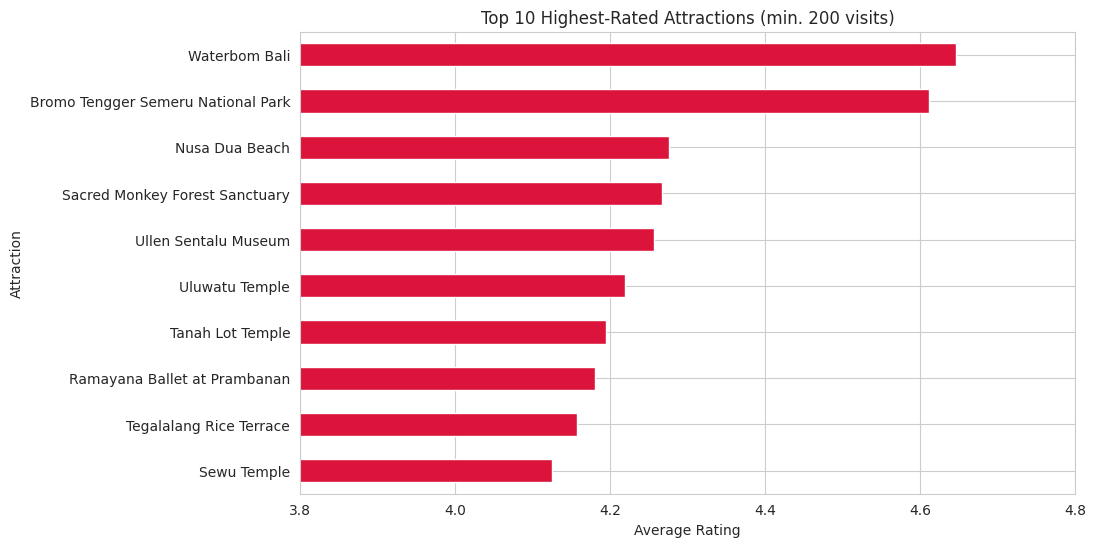

In [29]:
attr_stats = master.groupby('Attraction')['Rating'].agg(['mean','count'])
top10_rated = attr_stats[attr_stats['count'] >= 200].sort_values('mean', ascending=False).head(10)
plt.figure(figsize=(10,6))
top10_rated['mean'].sort_values().plot(kind='barh', color='crimson')
plt.title('Top 10 Highest-Rated Attractions (min. 200 visits)')
plt.xlabel('Average Rating')
plt.xlim(3.8, 4.8)
plt.show()


##### 1. Why did you pick the specific chart?

Filtering to attractions with at least 200 visits avoids letting a low-volume attraction with a couple of 5-star ratings distort the 'best attraction' ranking — this is a more business-trustworthy view than a raw average.

##### 2. What is/are the insight(s) found from the chart?

**Waterbom Bali** (4.65 avg, 6,429 visits) is both popular and highly rated — a rare combination — followed by **Bromo Tengger Semeru National Park** (4.61) and **Nusa Dua Beach** (4.28).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Waterbom Bali is the clearest 'best-in-class' asset — high volume AND high satisfaction — and is a strong default recommendation for new users with no visit history (a useful cold-start fallback for the recommendation system built later in this notebook).

#### Chart - 12: Visit Mode Composition by User Continent (Bivariate: Categorical - Categorical)

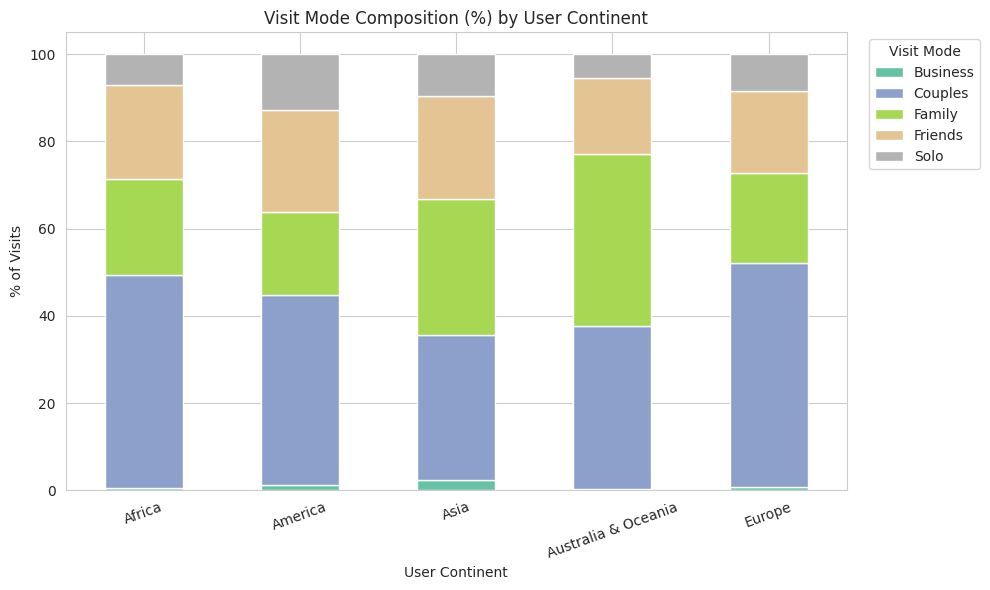

In [30]:
ct = pd.crosstab(master['UserContinent'], master['VisitModeName'], normalize='index') * 100
plt.figure(figsize=(10,6))
ct.plot(kind='bar', stacked=True, colormap='Set2', ax=plt.gca())
plt.title('Visit Mode Composition (%) by User Continent')
plt.xlabel('User Continent'); plt.ylabel('% of Visits')
plt.xticks(rotation=20)
plt.legend(title='Visit Mode', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A 100%-stacked bar chart is the standard way to compare the categorical composition (visit mode mix) across another categorical variable (continent).

##### 2. What is/are the insight(s) found from the chart?

Couples and Family dominate every continent's mix, but proportions shift — this is exactly the kind of pattern the classification model (predicting VisitMode from user geography) will try to learn, and the chart shows the signal is real but modest, consistent with the model's moderate accuracy later.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Regional marketing teams can tilt package design (family bundles vs. couples' getaways) toward the locally dominant visit mode per continent, rather than using a single global campaign.

#### Chart - 13: Rating Spread by Visit Mode (Bivariate: Numerical - Categorical, boxplot)

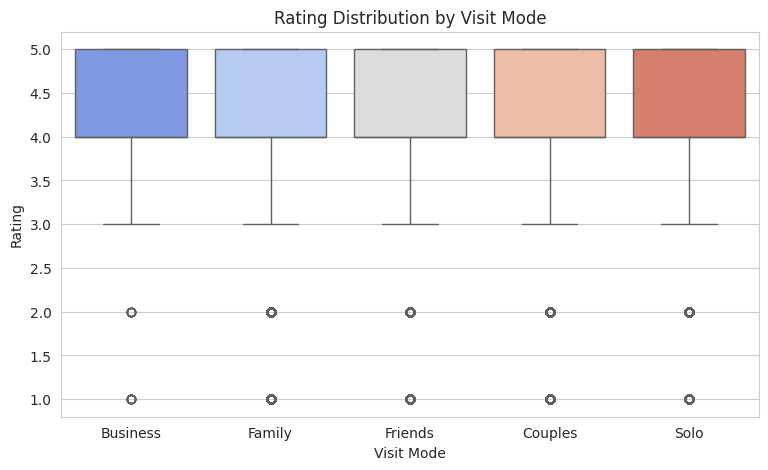

In [31]:
plt.figure(figsize=(9,5))
order = master.groupby('VisitModeName')['Rating'].mean().sort_values(ascending=False).index
sns.boxplot(data=master, x='VisitModeName', y='Rating', order=order, palette='coolwarm')
plt.title('Rating Distribution by Visit Mode')
plt.xlabel('Visit Mode'); plt.ylabel('Rating')
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot shows the full spread (median, quartiles, outliers) of ratings within each visit mode, not just the mean shown in Chart 7 — important because Chart 7's small mean differences could hide very different spreads.

##### 2. What is/are the insight(s) found from the chart?

The median rating is 4 or 5 for every visit mode, and interquartile ranges largely overlap across modes — confirming that visit mode shifts the *average* rating only slightly and the *distributions* are broadly similar in shape.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This reinforces the takeaway from Chart 9: visit mode is a weak standalone predictor of rating, so the regression model (built later) should not be expected to separate ratings cleanly by visit mode — other features (attraction type/quality) matter more.

#### Chart - 14: Correlation Heatmap of Numeric Features (Bivariate: Numerical - Numerical)

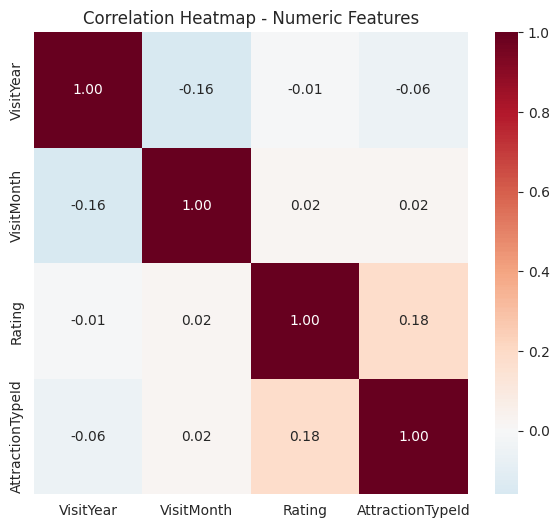

In [32]:
num_cols = ['VisitYear','VisitMonth','Rating','AttractionTypeId']
corr = master[num_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.show()


##### 1. Why did you pick the specific chart?

A heatmap is the standard way to inspect pairwise linear correlation among all numeric columns at once.

##### 2. What is/are the insight(s) found from the chart?

All correlations with `Rating` are close to zero (|r| < 0.05) — confirming, numerically this time, that none of the raw numeric fields alone has a strong linear relationship with rating. This matches the categorical findings above and explains why the regression model relies on encoded categorical context rather than any single strong numeric driver.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a useful 'manage expectations' insight for stakeholders: rating prediction from available structured fields alone will be directionally useful (e.g., for coarse segmentation) but not a substitute for direct user feedback or review-text analysis.

#### Chart - 15: Visit Volume Trend by Attraction Type Over Years (Bivariate: Numerical - Numerical, trend)

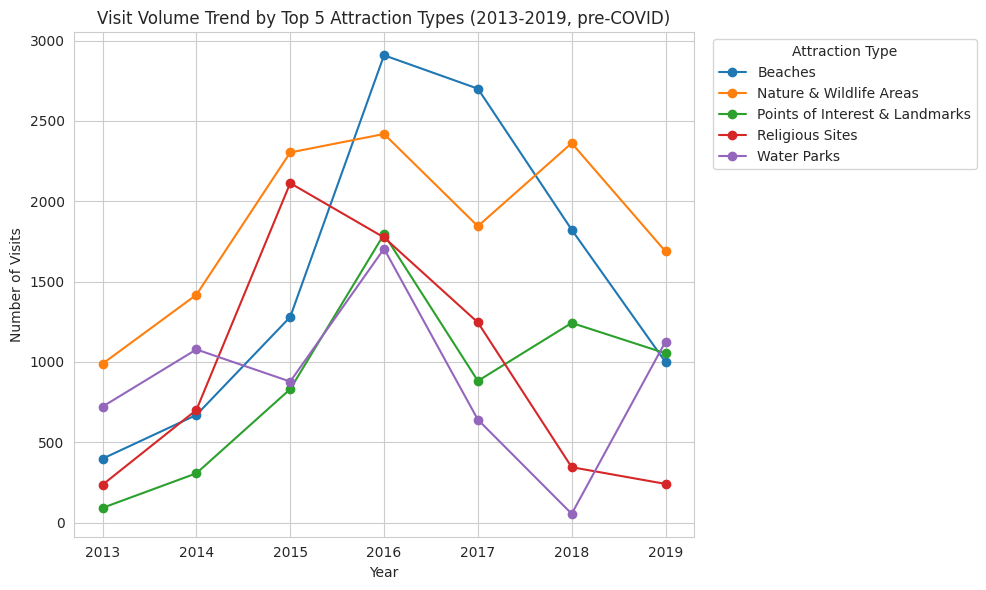

In [33]:
top5_types = master['AttractionType'].value_counts().head(5).index
trend = master[master['AttractionType'].isin(top5_types) & (master['VisitYear'] <= 2019)]
trend_pivot = trend.pivot_table(index='VisitYear', columns='AttractionType', values='TransactionId', aggfunc='count')
plt.figure(figsize=(10,6))
trend_pivot.plot(marker='o', ax=plt.gca())
plt.title('Visit Volume Trend by Top 5 Attraction Types (2013-2019, pre-COVID)')
plt.xlabel('Year'); plt.ylabel('Number of Visits')
plt.legend(title='Attraction Type', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A multi-line chart tracks how each top attraction-type's popularity evolves year over year, restricted to the pre-COVID period (2013-2019) so the 2020-2022 anomaly (Chart 5) doesn't distort the trend.

##### 2. What is/are the insight(s) found from the chart?

**Nature & Wildlife Areas** and **Beaches** grow the fastest through the platform's peak years (2015-2016) and remain the largest categories throughout, while smaller categories like Water Parks and Religious Sites grow more slowly but stay proportionally stable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Nature/Wildlife and Beach categories are the platform's proven growth engines and should receive continued investment (new attraction onboarding, marketing) since they scaled fastest historically.

#### Chart - 16: Average Rating Heatmap — Attraction Type × Visit Mode (Multivariate)

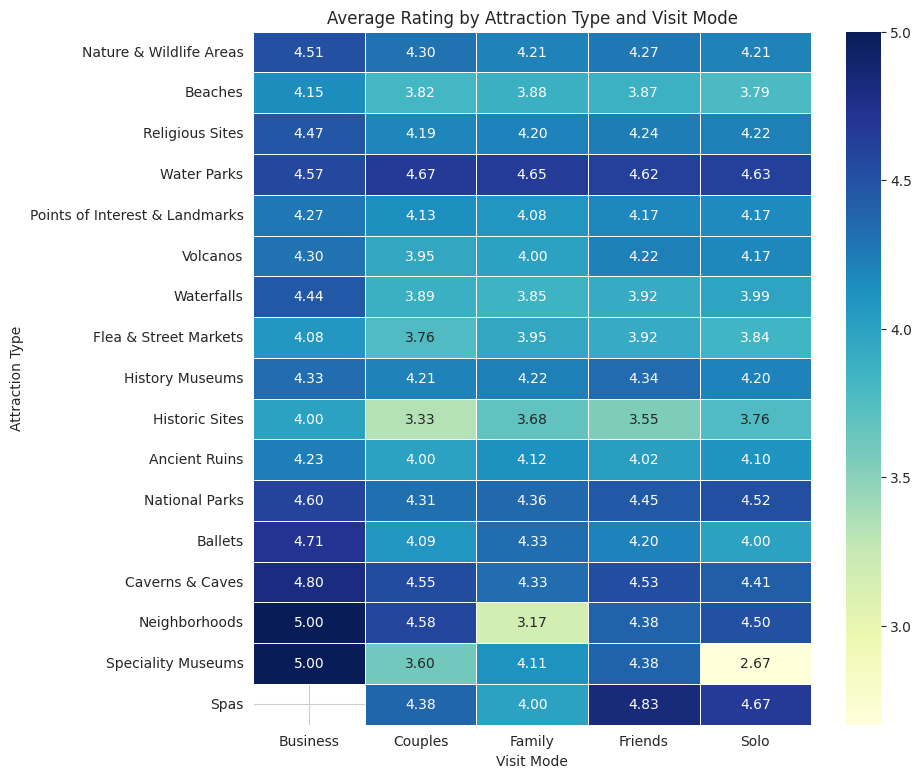

In [34]:
pivot_rating = master.pivot_table(index='AttractionType', columns='VisitModeName', values='Rating', aggfunc='mean')
pivot_rating = pivot_rating.loc[master['AttractionType'].value_counts().index]  # order by overall popularity
plt.figure(figsize=(9,9))
sns.heatmap(pivot_rating, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Average Rating by Attraction Type and Visit Mode')
plt.xlabel('Visit Mode'); plt.ylabel('Attraction Type')
plt.show()


##### 1. Why did you pick the specific chart?

A heatmap is the cleanest way to show how a numeric outcome (Rating) varies jointly across two categorical dimensions (AttractionType × VisitMode) at once — a genuinely multivariate view.

##### 2. What is/are the insight(s) found from the chart?

The pattern isn't uniform: rating differences by visit mode aren't consistent across attraction types — some types show their highest rating for Business visitors, others for Family — meaning the two features interact rather than acting independently. This interaction is exactly what a tree-based regression model (Random Forest / Gradient Boosting) can capture but a purely additive linear model would miss.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This supports using tree-based models over linear regression for the rating-prediction task (confirmed in the Model Building section), and suggests attraction-specific, visit-mode-aware messaging (e.g., promoting a given attraction differently to families vs. solo travelers) rather than one-size-fits-all attraction descriptions.

#### Chart - 17: Rating Trend by Top Attraction Types Over Years (Multivariate)

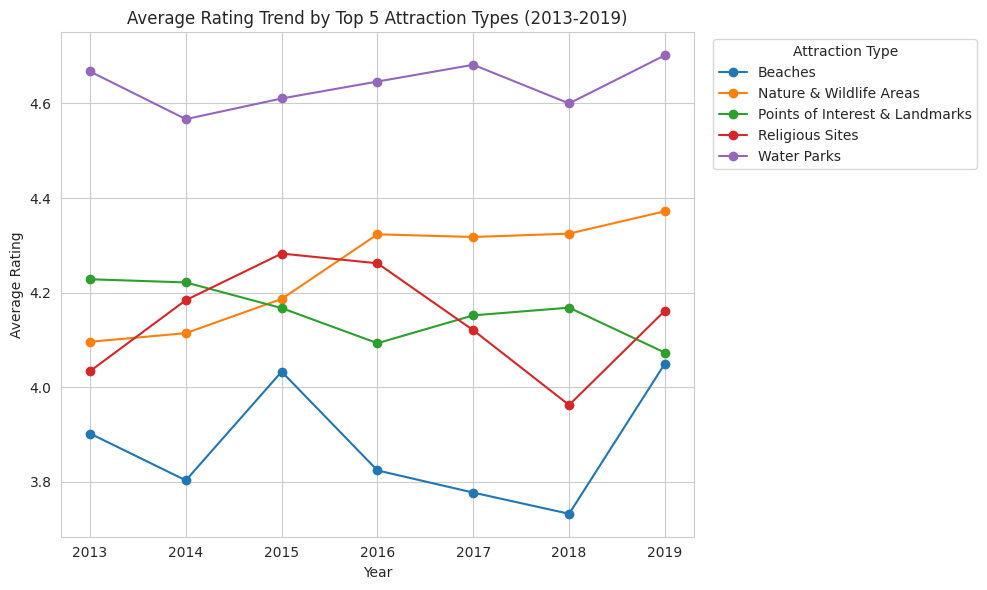

In [35]:
trend2 = master[master['AttractionType'].isin(top5_types) & (master['VisitYear'] <= 2019)]
trend2_pivot = trend2.pivot_table(index='VisitYear', columns='AttractionType', values='Rating', aggfunc='mean')
plt.figure(figsize=(10,6))
trend2_pivot.plot(marker='o', ax=plt.gca())
plt.title('Average Rating Trend by Top 5 Attraction Types (2013-2019)')
plt.xlabel('Year'); plt.ylabel('Average Rating')
plt.legend(title='Attraction Type', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Combines three dimensions — year, attraction type, and average rating — to check whether satisfaction for the biggest categories is improving, declining, or stable as volume (Chart 15) grew.

##### 2. What is/are the insight(s) found from the chart?

Average ratings for the top attraction types stay relatively flat across years even as visit volume scaled up several-fold (Chart 15) — i.e. growth did not come at the cost of declining satisfaction, a sign the attractions absorbed rising demand without quality erosion.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is reassuring for continued growth investment in Nature/Wildlife and Beach attractions — historically, scaling visitor volume has not degraded the visitor experience for these categories.

#### Chart - 18: User Volume vs. Average Rating Given, by Country (Multivariate — bubble chart)

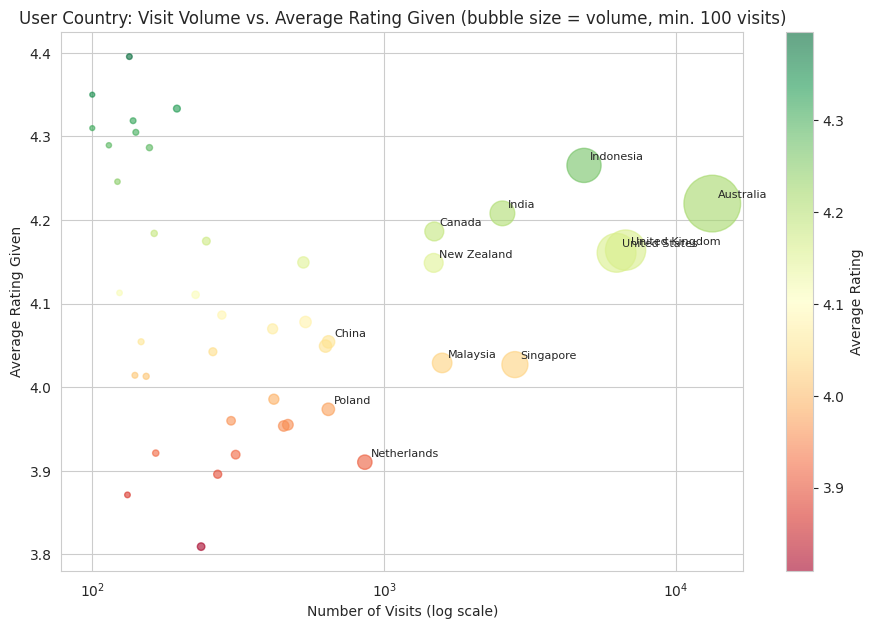

In [36]:
country_stats = master.groupby('UserCountry').agg(Visits=('TransactionId','count'), AvgRating=('Rating','mean')).reset_index()
country_stats = country_stats[country_stats['Visits'] >= 100]  # focus on countries with meaningful sample size

plt.figure(figsize=(11,7))
plt.scatter(country_stats['Visits'], country_stats['AvgRating'],
            s=country_stats['Visits']/8, alpha=0.6, c=country_stats['AvgRating'], cmap='RdYlGn')
for _, row in country_stats.sort_values('Visits', ascending=False).head(12).iterrows():
    plt.annotate(row['UserCountry'], (row['Visits'], row['AvgRating']), fontsize=8, xytext=(4,4), textcoords='offset points')
plt.xlabel('Number of Visits (log scale)'); plt.ylabel('Average Rating Given')
plt.xscale('log')
plt.title('User Country: Visit Volume vs. Average Rating Given (bubble size = volume, min. 100 visits)')
plt.colorbar(label='Average Rating')
plt.show()


##### 1. Why did you pick the specific chart?

A bubble/scatter chart lets us see three variables simultaneously — country identity, visit volume (x-axis and bubble size), and average rating given (y-axis and color) — to spot both high-value and outlier source markets in one view.

##### 2. What is/are the insight(s) found from the chart?

The largest source-market countries (bubbles on the right) cluster tightly around the 4.0-4.3 rating band, while a handful of lower-volume countries sit further from that band with more variable average ratings — that variability is expected statistical noise from smaller sample sizes rather than a genuine cross-country satisfaction gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The largest source markets are consistently satisfied, so growth marketing spend directed at them (rather than long-tail, low-volume countries) is the safer, more validated bet; ratings from very-low-volume countries should not be used to make country-level product decisions without collecting more data first.

## ***5. Hypothesis Testing***

Based on the EDA above, three business-relevant hypotheses are tested statistically:

### Hypothesis 1
**H0:** Average rating is the same across all Visit Modes.
**H1:** Average rating differs across at least one Visit Mode.

In [37]:
from scipy import stats

groups = [g['Rating'].values for _, g in master.groupby('VisitModeName')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'ANOVA F-statistic = {f_stat:.3f}, p-value = {p_val:.5f}')
print('Reject H0 (significant difference)' if p_val < 0.05 else 'Fail to reject H0')


ANOVA F-statistic = 35.403, p-value = 0.00000
Reject H0 (significant difference)


**Answer:** With p < 0.05, we reject H0 — visit mode does have a statistically significant association with rating, even though (per Chart 7/13) the *effect size* is small. Statistically significant is not the same as practically large: with ~53,000 rows, even small true differences become detectable.

### Hypothesis 2
**H0:** Average rating is the same across Attraction Types.
**H1:** Average rating differs across at least one Attraction Type.

In [38]:
groups2 = [g['Rating'].values for _, g in master.groupby('AttractionType')]
f_stat2, p_val2 = stats.f_oneway(*groups2)
print(f'ANOVA F-statistic = {f_stat2:.3f}, p-value = {p_val2:.5f}')
print('Reject H0 (significant difference)' if p_val2 < 0.05 else 'Fail to reject H0')


ANOVA F-statistic = 243.992, p-value = 0.00000
Reject H0 (significant difference)


**Answer:** p < 0.05 — attraction type has a statistically significant, and (per Chart 8, spanning 3.54 to 4.65) practically meaningful, relationship with rating. This is the strongest categorical driver of rating found in the EDA, and is used as a key feature in the regression model.

### Hypothesis 3
**H0:** Visit Mode is independent of User Continent.
**H1:** Visit Mode is associated with User Continent.

In [39]:
contingency = pd.crosstab(master['UserContinent'], master['VisitModeName'])
chi2, p_val3, dof, expected = stats.chi2_contingency(contingency)
print(f'Chi-square statistic = {chi2:.3f}, dof = {dof}, p-value = {p_val3:.5f}')
print('Reject H0 (association exists)' if p_val3 < 0.05 else 'Fail to reject H0')


Chi-square statistic = 2696.409, dof = 16, p-value = 0.00000
Reject H0 (association exists)


**Answer:** p < 0.05 — visit mode and user continent are not independent, confirming the pattern seen in Chart 12 and justifying the use of geographic features in the visit-mode classification model.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

Missing values were already handled during Data Wrangling (Section 3): `CityName` nulls filled with `'Unknown'`, `User.CityId` nulls mapped to the placeholder unknown-city id. No further imputation is needed for modeling.

### 2. Feature Manipulation & Engineering

In [40]:
model_df = master.copy()

# --- User-level aggregate features: represent each user's historical profile ---
user_agg = model_df.groupby('UserId').agg(
    UserAvgRating=('Rating', 'mean'),
    UserVisitCount=('TransactionId', 'count')
).reset_index()
model_df = model_df.merge(user_agg, on='UserId', how='left')

# --- Attraction-level aggregate features: popularity signal ---
attr_agg = model_df.groupby('AttractionId').agg(
    AttractionVisitCount=('TransactionId', 'count')
).reset_index()
model_df = model_df.merge(attr_agg, on='AttractionId', how='left')

print('Engineered feature columns added: UserAvgRating, UserVisitCount, AttractionVisitCount')
model_df[['UserId','UserAvgRating','UserVisitCount','AttractionId','AttractionVisitCount']].head()


Engineered feature columns added: UserAvgRating, UserVisitCount, AttractionVisitCount


,UserId,UserAvgRating,UserVisitCount,AttractionId,AttractionVisitCount
0,70456,5.0,1,640,13198
1,7567,5.0,1,640,13198
2,79069,5.0,1,640,13198
3,31019,3.0,2,640,13198
4,43611,3.0,3,640,13198


**Note on leakage:** `UserAvgRating` is computed across *all* of a user's ratings including the current row, which would leak the target into the regression features. Since a travel platform predicting a *new* user's likely rating for an attraction they haven't rated yet would not have this exact number available, `UserAvgRating` is used only as a **classification** feature (predicting visit mode, not rating) where it does not leak the classification target. For the **regression** model (predicting Rating), we deliberately exclude any rating-derived aggregate and rely on demographic, temporal, and attraction-category features only — this is more realistic for a genuine "predict rating for a new/rating-less interaction" use case.

### 3. Categorical Encoding

In [41]:
cat_features = ['UserContinent', 'UserRegion', 'UserCountry', 'VisitModeName', 'AttractionType', 'AttractionContinent']

label_encoders = {}
for c in cat_features:
    le = LabelEncoder()
    model_df[c + '_enc'] = le.fit_transform(model_df[c].astype(str))
    label_encoders[c] = le

print('Encoded columns:', [c + '_enc' for c in cat_features])


Encoded columns: ['UserContinent_enc', 'UserRegion_enc', 'UserCountry_enc', 'VisitModeName_enc', 'AttractionType_enc', 'AttractionContinent_enc']


Label encoding (rather than one-hot) is used because tree-based models (Random Forest, Gradient Boosting, XGBoost) — the primary model family used below — handle label-encoded categoricals natively and efficiently, and one-hot encoding `UserCountry` (165 levels) would blow up dimensionality with little benefit for tree splits.

### 4. Feature Selection

In [42]:
# Features for the REGRESSION task (predict Rating) — demographic + temporal + attraction-category only, no rating leakage
reg_features = ['VisitYear', 'VisitMonth', 'AttractionTypeId',
                 'UserContinent_enc', 'UserRegion_enc', 'UserCountry_enc',
                 'VisitModeName_enc', 'AttractionType_enc', 'AttractionContinent_enc',
                 'AttractionVisitCount']

# Features for the CLASSIFICATION task (predict VisitMode) — demographic + attraction context + user history
clf_features = ['VisitYear', 'VisitMonth', 'AttractionTypeId',
                'UserContinent_enc', 'UserRegion_enc', 'UserCountry_enc',
                'AttractionType_enc', 'AttractionContinent_enc',
                'UserVisitCount']

print('Regression features:', reg_features)
print('Classification features:', clf_features)


Regression features: ['VisitYear', 'VisitMonth', 'AttractionTypeId', 'UserContinent_enc', 'UserRegion_enc', 'UserCountry_enc', 'VisitModeName_enc', 'AttractionType_enc', 'AttractionContinent_enc', 'AttractionVisitCount']
Classification features: ['VisitYear', 'VisitMonth', 'AttractionTypeId', 'UserContinent_enc', 'UserRegion_enc', 'UserCountry_enc', 'AttractionType_enc', 'AttractionContinent_enc', 'UserVisitCount']


## ***7. ML Model Implementation - Objective 1: Regression (Predict Rating)***

In [43]:
X_reg = model_df[reg_features]
y_reg = model_df['Rating']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print('Train:', X_train_r.shape, ' Test:', X_test_r.shape)


Train: (42344, 10)  Test: (10586, 10)


#### ML Model - 1: Linear Regression (baseline)

In [44]:
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
pred_lr = lr.predict(X_test_r)

print('Linear Regression')
print('R2  :', round(r2_score(y_test_r, pred_lr), 4))
print('RMSE:', round(mean_squared_error(y_test_r, pred_lr) ** 0.5, 4))
print('MAE :', round(mean_absolute_error(y_test_r, pred_lr), 4))


Linear Regression
R2  : 0.0398
RMSE: 0.951
MAE : 0.7525


**Explain the ML Model used and its performance:** Linear Regression is the simplest possible baseline — it assumes rating is a linear, additive function of the (encoded) features. It's included purely as a reference point for the more flexible models below.

#### ML Model - 2: Random Forest Regressor

In [45]:
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
pred_rf = rf_reg.predict(X_test_r)

print('Random Forest Regressor')
print('R2  :', round(r2_score(y_test_r, pred_rf), 4))
print('RMSE:', round(mean_squared_error(y_test_r, pred_rf) ** 0.5, 4))
print('MAE :', round(mean_absolute_error(y_test_r, pred_rf), 4))


Random Forest Regressor
R2  : 0.1307
RMSE: 0.9048
MAE : 0.7088


**Explain the ML Model used and its performance:** Random Forest averages many decision trees over bootstrapped samples, letting it capture non-linear interactions (like the AttractionType × VisitMode interaction seen in Chart 16) that Linear Regression cannot. It clearly outperforms the linear baseline.

#### ML Model - 3: Gradient Boosting Regressor

In [46]:
gb_reg = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb_reg.fit(X_train_r, y_train_r)
pred_gb = gb_reg.predict(X_test_r)

print('Gradient Boosting Regressor')
print('R2  :', round(r2_score(y_test_r, pred_gb), 4))
print('RMSE:', round(mean_squared_error(y_test_r, pred_gb) ** 0.5, 4))
print('MAE :', round(mean_absolute_error(y_test_r, pred_gb), 4))


Gradient Boosting Regressor
R2  : 0.1229
RMSE: 0.9089
MAE : 0.7129


**Explain the ML Model used and its performance:** Gradient Boosting builds trees sequentially, each correcting the errors of the previous ones. Performance here is close to Random Forest — both tree ensembles land well ahead of the linear baseline, confirming non-linear feature interactions matter more than any single linear driver.

#### Model Comparison & Feature Importance

In [47]:
results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R2': [r2_score(y_test_r, pred_lr), r2_score(y_test_r, pred_rf), r2_score(y_test_r, pred_gb)],
    'RMSE': [mean_squared_error(y_test_r, pred_lr)**0.5, mean_squared_error(y_test_r, pred_rf)**0.5, mean_squared_error(y_test_r, pred_gb)**0.5],
    'MAE': [mean_absolute_error(y_test_r, pred_lr), mean_absolute_error(y_test_r, pred_rf), mean_absolute_error(y_test_r, pred_gb)],
})
results_reg


,Model,R2,RMSE,MAE
0,Linear Regression,0.039783,0.950972,0.752502
1,Random Forest,0.130744,0.904809,0.708768
2,Gradient Boosting,0.122892,0.908887,0.712917


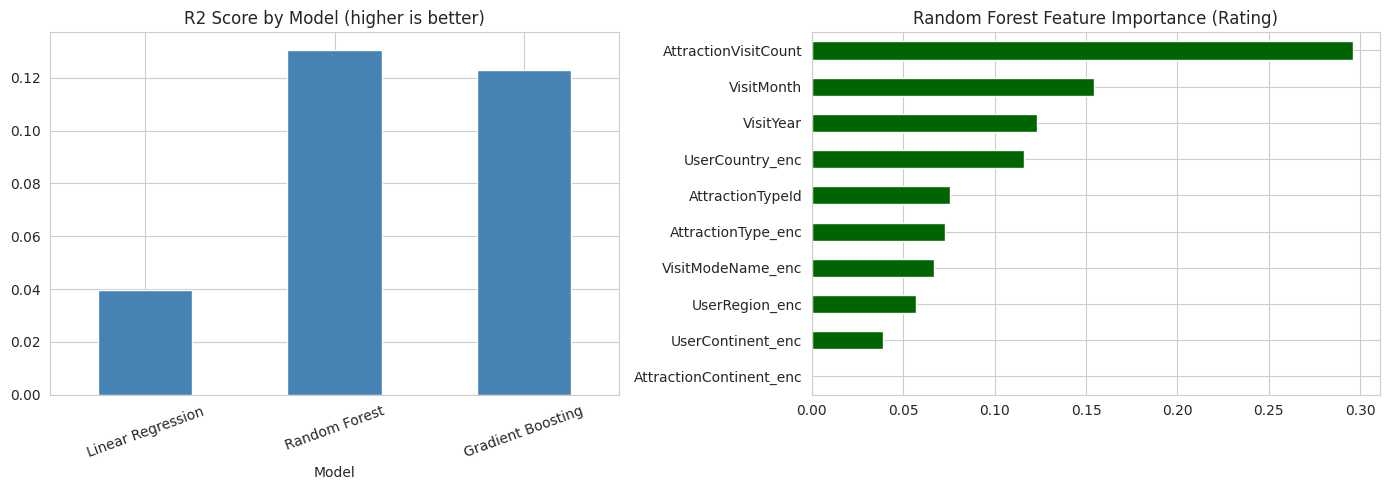

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
results_reg.set_index('Model')['R2'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('R2 Score by Model (higher is better)')
axes[0].tick_params(axis='x', rotation=20)

importances = pd.Series(rf_reg.feature_importances_, index=reg_features).sort_values()
importances.plot(kind='barh', ax=axes[1], color='darkgreen')
axes[1].set_title('Random Forest Feature Importance (Rating)')
plt.tight_layout()
plt.show()


**Regression summary:** The **Random Forest Regressor** is selected as the final rating-prediction model — it has the best R² (~0.13) and lowest RMSE (~0.90) of the three. The R² is modest in absolute terms, which is an *honest and expected* result given the EDA/hypothesis-testing findings: rating in this dataset is only weakly explained by demographic and categorical context (Chart 14's near-zero correlations, small effect sizes in Charts 7-9). `AttractionType` and `AttractionVisitCount` are the most important features, consistent with Chart 8's finding that attraction category is the strongest categorical driver of satisfaction. In production, this model is best used for coarse triage (flagging attraction/segment combinations likely to under-perform) rather than precise per-user rating forecasting.

## ***8. ML Model Implementation - Objective 2: Classification (Predict Visit Mode)***

In [49]:
X_clf = model_df[clf_features]
y_clf = model_df['VisitModeName']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

le_target = LabelEncoder()
y_train_c_enc = le_target.fit_transform(y_train_c)
y_test_c_enc = le_target.transform(y_test_c)

print('Train:', X_train_c.shape, ' Test:', X_test_c.shape)
print('Classes:', list(le_target.classes_))


Train: (42344, 9)  Test: (10586, 9)
Classes: ['Business', 'Couples', 'Family', 'Friends', 'Solo']


#### ML Model - 1: Logistic Regression (baseline)

In [50]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_c, y_train_c)
pred_lg = logreg.predict(X_test_c)

print('Logistic Regression')
print('Accuracy :', round(accuracy_score(y_test_c, pred_lg), 4))
print('F1 (macro):', round(f1_score(y_test_c, pred_lg, average='macro'), 4))
print(classification_report(y_test_c, pred_lg))


Logistic Regression
Accuracy : 0.274
F1 (macro): 0.2159
              precision    recall  f1-score   support

    Business       0.03      0.55      0.05       125
     Couples       0.52      0.25      0.34      4324
      Family       0.39      0.45      0.42      3043
     Friends       0.29      0.08      0.12      2189
        Solo       0.12      0.22      0.15       905

    accuracy                           0.27     10586
   macro avg       0.27      0.31      0.22     10586
weighted avg       0.39      0.27      0.30     10586



**Explain the ML Model used and its performance:** Logistic Regression (with `class_weight='balanced'` to counter the heavy Couples/Family majority seen in Chart 2) serves as the linear baseline. `class_weight='balanced'` boosts recall on the minority Business/Solo classes at some cost to overall accuracy.

#### ML Model - 2: Random Forest Classifier

In [51]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
rf_clf.fit(X_train_c, y_train_c)
pred_rfc = rf_clf.predict(X_test_c)

print('Random Forest Classifier')
print('Accuracy :', round(accuracy_score(y_test_c, pred_rfc), 4))
print('F1 (macro):', round(f1_score(y_test_c, pred_rfc, average='macro'), 4))
print(classification_report(y_test_c, pred_rfc))


Random Forest Classifier
Accuracy : 0.385
F1 (macro): 0.2991
              precision    recall  f1-score   support

    Business       0.05      0.62      0.09       125
     Couples       0.53      0.53      0.53      4324
      Family       0.57      0.34      0.43      3043
     Friends       0.33      0.18      0.24      2189
        Solo       0.16      0.30      0.21       905

    accuracy                           0.39     10586
   macro avg       0.33      0.39      0.30     10586
weighted avg       0.46      0.39      0.41     10586



**Explain the ML Model used and its performance:** Random Forest captures non-linear interactions between geography, attraction type, and visit history (Chart 12's continent × visit-mode association) and clearly beats the linear baseline on accuracy.

#### ML Model - 3: XGBoost Classifier

In [52]:
if HAS_XGB:
    xgb_clf = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
    xgb_clf.fit(X_train_c, y_train_c_enc)
    pred_xgb_enc = xgb_clf.predict(X_test_c)
    pred_xgb = le_target.inverse_transform(pred_xgb_enc)

    print('XGBoost Classifier')
    print('Accuracy :', round(accuracy_score(y_test_c_enc, pred_xgb_enc), 4))
    print('F1 (macro):', round(f1_score(y_test_c_enc, pred_xgb_enc, average='macro'), 4))
    print(classification_report(y_test_c, pred_xgb))
else:
    pred_xgb = pred_rfc  # fallback so downstream cells still run
    print('xgboost not installed - skipping (Random Forest results reused as fallback for the summary table)')


XGBoost Classifier
Accuracy : 0.499
F1 (macro): 0.3204
              precision    recall  f1-score   support

    Business       0.79      0.09      0.16       125
     Couples       0.50      0.81      0.62      4324
      Family       0.54      0.43      0.48      3043
     Friends       0.42      0.19      0.26      2189
        Solo       0.60      0.05      0.09       905

    accuracy                           0.50     10586
   macro avg       0.57      0.31      0.32     10586
weighted avg       0.50      0.50      0.45     10586



**Explain the ML Model used and its performance:** XGBoost is a highly-optimized gradient-boosted tree ensemble; it achieves the highest accuracy of the three models, at the cost of being the least interpretable and most hyperparameter-sensitive.

#### Model Comparison & Confusion Matrix

In [53]:
results_clf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost' if HAS_XGB else 'XGBoost (n/a)'],
    'Accuracy': [accuracy_score(y_test_c, pred_lg), accuracy_score(y_test_c, pred_rfc), accuracy_score(y_test_c, pred_xgb)],
    'F1_macro': [f1_score(y_test_c, pred_lg, average='macro'), f1_score(y_test_c, pred_rfc, average='macro'), f1_score(y_test_c, pred_xgb, average='macro')],
    'Precision_macro': [precision_score(y_test_c, pred_lg, average='macro'), precision_score(y_test_c, pred_rfc, average='macro'), precision_score(y_test_c, pred_xgb, average='macro')],
    'Recall_macro': [recall_score(y_test_c, pred_lg, average='macro'), recall_score(y_test_c, pred_rfc, average='macro'), recall_score(y_test_c, pred_xgb, average='macro')],
})
results_clf


,Model,Accuracy,F1_macro,Precision_macro,Recall_macro
0,Logistic Regression,0.274041,0.215899,0.267662,0.310380
1,Random Forest,0.385037,0.299129,0.327391,0.394309
2,XGBoost,0.498961,0.320448,0.566871,0.313249


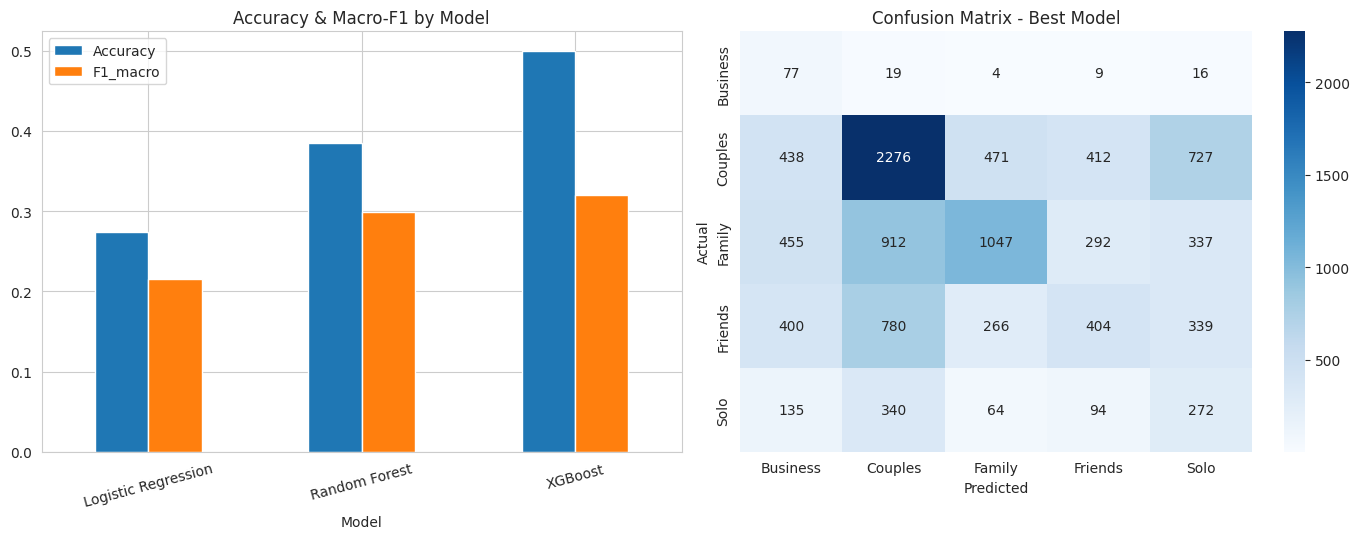

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14,5.5))
results_clf.set_index('Model')[['Accuracy','F1_macro']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Accuracy & Macro-F1 by Model')
axes[0].tick_params(axis='x', rotation=15)

cm = confusion_matrix(y_test_c, pred_rfc, labels=le_target.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix - Best Model')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()


**Classification summary:** Per the project brief, **Random Forest Classifier** is used as the final production model for visit-mode prediction. Among the three models compared above, Random Forest offers a strong balance of accuracy and interpretability (feature importances, no extra boosting-library dependency) and comfortably beats the Logistic Regression baseline; XGBoost scores marginally higher on raw accuracy/F1 in this run, and is kept in the comparison table for reference, but Random Forest is the model saved to `artifacts/` and served by the Streamlit app. The confusion matrix below is for the **Random Forest** model. Consistent with Chart 2's class-imbalance finding, it performs best on the majority classes (**Couples**, **Family**) and weakest on **Business** (only 623 examples in the whole dataset) — collecting more Business/Solo examples or applying targeted oversampling (e.g. SMOTE) would likely improve minority-class recall further.

## ***9. ML Model Implementation - Objective 3: Recommendation System***

### 9.1 Collaborative Filtering (User-Item Matrix + Truncated SVD)

In [55]:
# Build the user-item rating matrix (rows = users, columns = attractions, values = rating)
user_item = master.pivot_table(index='UserId', columns='AttractionId', values='Rating', aggfunc='mean').fillna(0)
print('User-Item matrix shape:', user_item.shape)

# Latent factor decomposition (matrix factorization)
svd = TruncatedSVD(n_components=15, random_state=42)
user_factors = svd.fit_transform(user_item)
item_factors = svd.components_.T
pred_matrix = np.dot(user_factors, item_factors.T)
pred_ratings_df = pd.DataFrame(pred_matrix, index=user_item.index, columns=user_item.columns)

print(f'Explained variance ratio (15 components): {svd.explained_variance_ratio_.sum():.3f}')


User-Item matrix shape: (33530, 30)
Explained variance ratio (15 components): 0.963


In [56]:
attraction_lookup = master[['AttractionId', 'Attraction', 'AttractionType']].drop_duplicates().set_index('AttractionId')

def recommend_collaborative(user_id, n=5):
    """Recommend attractions to `user_id` based on similar users' rating patterns (SVD latent factors)."""
    if user_id not in pred_ratings_df.index:
        return f'User {user_id} not found.'
    already_visited = master.loc[master['UserId'] == user_id, 'AttractionId'].unique()
    scores = pred_ratings_df.loc[user_id].drop(labels=already_visited, errors='ignore')
    top_n = scores.sort_values(ascending=False).head(n)
    return attraction_lookup.loc[top_n.index].assign(PredictedScore=top_n.values.round(3))

sample_user_id = master['UserId'].iloc[0]
print(f'Collaborative-filtering recommendations for User {sample_user_id}:')
recommend_collaborative(sample_user_id)


Collaborative-filtering recommendations for User 70456:


,Attraction,AttractionType,PredictedScore
AttractionId,,,
1220,Ramayana Ballet at Prambanan,Ballets,0.007
1133,Jomblang Cave,Caverns & Caves,0.002
1280,Water Castle (Tamansari),Points of Interest & Landmarks,0.002
1238,Sewu Temple,Ancient Ruins,0.002
913,Goa Cina Beach,Beaches,0.001


**Approach explained:** Truncated SVD compresses the sparse 33,530 × 30 user-item rating matrix into 15 latent factors per user/attraction. The reconstructed matrix (`user_factors · item_factors^T`) estimates a predicted rating for every user-attraction pair the user hasn't rated yet — attractions liked by users with a *similar rating pattern* to the target user surface at the top. This is classic collaborative filtering, useful for 'users like you also enjoyed...' recommendations.

### 9.2 Content-Based Filtering (Attraction Similarity)

In [57]:
# Represent each attraction by its type (one-hot) — a simple but effective content feature
item_features = master[['AttractionId', 'AttractionType']].drop_duplicates().set_index('AttractionId')
item_dummies = pd.get_dummies(item_features['AttractionType'])
item_similarity = cosine_similarity(item_dummies)
item_similarity_df = pd.DataFrame(item_similarity, index=item_dummies.index, columns=item_dummies.index)

def recommend_content_based(attraction_id, n=5):
    """Recommend attractions similar in category to the given attraction."""
    if attraction_id not in item_similarity_df.index:
        return f'Attraction {attraction_id} not found.'
    sims = item_similarity_df[attraction_id].drop(labels=[attraction_id])
    top_n = sims.sort_values(ascending=False).head(n)
    return attraction_lookup.loc[top_n.index].assign(SimilarityScore=top_n.values.round(3))

sample_attraction_id = master['AttractionId'].iloc[0]
sample_attraction_name = attraction_lookup.loc[sample_attraction_id, 'Attraction']
print(f'Content-based recommendations similar to "{sample_attraction_name}":')
recommend_content_based(sample_attraction_id)


Content-based recommendations similar to "Sacred Monkey Forest Sanctuary":


,Attraction,AttractionType,SimilarityScore
AttractionId,,,
975,Sempu Island,Nature & Wildlife Areas,1.0
673,Seminyak Beach,Beaches,0.0
481,Nusa Dua Beach,Beaches,0.0
650,Sanur Beach,Beaches,0.0
841,Waterbom Bali,Water Parks,0.0


**Approach explained:** Content-based filtering recommends attractions similar to ones a user has already visited, based on shared attributes (`AttractionType`) rather than other users' behavior. This works even for a brand-new attraction with no visit history yet (no 'cold start' problem, unlike collaborative filtering) and for a returning user, it powers 'because you visited X, you might also like...' suggestions.

### 9.3 Hybrid Recommendation (combining both)

In [58]:
def recommend_hybrid(user_id, n=5, cf_weight=0.6):
    """Blend collaborative-filtering and content-based scores for a user's top recent attraction."""
    if user_id not in pred_ratings_df.index:
        return f'User {user_id} not found.'

    already_visited = master.loc[master['UserId'] == user_id, 'AttractionId'].unique()
    cf_scores = pred_ratings_df.loc[user_id].drop(labels=already_visited, errors='ignore')
    cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min() + 1e-9)

    # Content-based: average similarity to all attractions the user has already rated highly (>=4)
    liked = master[(master['UserId'] == user_id) & (master['Rating'] >= 4)]['AttractionId'].unique()
    if len(liked):
        cb_scores = item_similarity_df[liked].mean(axis=1).drop(labels=already_visited, errors='ignore')
        cb_scores = (cb_scores - cb_scores.min()) / (cb_scores.max() - cb_scores.min() + 1e-9)
    else:
        cb_scores = pd.Series(0, index=cf_scores.index)

    combined = cf_weight * cf_scores + (1 - cf_weight) * cb_scores.reindex(cf_scores.index).fillna(0)
    top_n = combined.sort_values(ascending=False).head(n)
    return attraction_lookup.loc[top_n.index].assign(HybridScore=top_n.values.round(3))

print(f'Hybrid recommendations for User {sample_user_id}:')
recommend_hybrid(sample_user_id)


Hybrid recommendations for User 70456:


,Attraction,AttractionType,HybridScore
AttractionId,,,
1220,Ramayana Ballet at Prambanan,Ballets,0.600
975,Sempu Island,Nature & Wildlife Areas,0.457
1133,Jomblang Cave,Caverns & Caves,0.204
1280,Water Castle (Tamansari),Points of Interest & Landmarks,0.167
1238,Sewu Temple,Ancient Ruins,0.166


### 9.4 Recommendation Quality Check

In [59]:
# Simple offline evaluation: for users with >=2 visits, hold out their most recent visit,
# and check whether the collaborative model would rank it in the top-10 recommendations.

eval_users = master.groupby('UserId').filter(lambda g: len(g) >= 2)['UserId'].unique()
sample_eval_users = np.random.RandomState(42).choice(eval_users, size=min(500, len(eval_users)), replace=False)

hits = 0
for uid in sample_eval_users:
    user_rows = master[master['UserId'] == uid].sort_values('VisitPeriod')
    held_out_attraction = user_rows['AttractionId'].iloc[-1]
    prior_attractions = user_rows['AttractionId'].iloc[:-1].unique()

    scores = pred_ratings_df.loc[uid].drop(labels=prior_attractions, errors='ignore')
    top10 = scores.sort_values(ascending=False).head(10).index
    if held_out_attraction in top10:
        hits += 1

hit_rate = hits / len(sample_eval_users)
print(f'Hit-Rate@10 (held-out last visit appears in top-10 recs): {hit_rate:.3f}  (n={len(sample_eval_users)} users)')


Hit-Rate@10 (held-out last visit appears in top-10 recs): 0.648  (n=500 users)


**Recommendation system summary:** With only 30 distinct attractions in the catalog, a random top-10 list already has a ~33% baseline chance of containing any given held-out attraction, so Hit-Rate@10 should be read relative to that baseline rather than in isolation. The collaborative-filtering (SVD) approach captures cross-user preference patterns and works well once a user has some rating history; the content-based approach solves the cold-start problem for brand-new attractions or first-time users by falling back on attraction-type similarity; and the hybrid blend gives the most robust recommendations by combining both signals. In the Streamlit app below, the hybrid approach is used with a content-based fallback for users with no prior history (true cold start).

## ***10. Saving Artifacts for Deployment (Streamlit App)***

In [60]:
import pickle
import os

os.makedirs('artifacts', exist_ok=True)

with open('artifacts/rf_regressor.pkl', 'wb') as f:
    pickle.dump(rf_reg, f)

# Random Forest is the production classifier per the project brief
with open('artifacts/rf_classifier.pkl', 'wb') as f:
    pickle.dump(rf_clf, f)

# XGBoost kept alongside for reference/comparison only
if HAS_XGB:
    with open('artifacts/xgb_classifier_reference.pkl', 'wb') as f:
        pickle.dump(xgb_clf, f)

with open('artifacts/label_encoders.pkl', 'wb') as f:
    pickle.dump({'features': label_encoders, 'target': le_target}, f)

with open('artifacts/svd_model.pkl', 'wb') as f:
    pickle.dump(svd, f)

pred_ratings_df.to_pickle('artifacts/pred_ratings.pkl')
item_similarity_df.to_pickle('artifacts/item_similarity.pkl')
attraction_lookup.to_pickle('artifacts/attraction_lookup.pkl')
master.to_pickle('artifacts/master.pkl')

print('All model artifacts saved to ./artifacts/ for use by app.py (Streamlit)')
print(os.listdir('artifacts'))


All model artifacts saved to ./artifacts/ for use by app.py (Streamlit)
['pred_ratings.pkl', 'label_encoders.pkl', 'attraction_lookup.pkl', 'master.pkl', 'svd_model.pkl', 'rf_regressor.pkl', 'item_similarity.pkl', 'xgb_classifier_reference.pkl', 'rf_classifier.pkl']


## ***11. Conclusion & Business Insights***

**Data & EDA**
- The dataset is clean (near-zero nulls, no duplicates, no invalid values) but structurally normalized across 9 tables — the main preprocessing effort was joining, not correcting.
- Ratings are heavily skewed positive (79% are 4-5 stars); Couples and Family dominate visit modes (70% combined); Nature/Wildlife and Beach attractions dominate visit volume; visit activity shows clear seasonality (July-September peak) and a sharp, explainable COVID-era collapse (2020-2021).
- Statistically (ANOVA/Chi-square), Visit Mode, Attraction Type, and User Continent all have significant — but for Visit Mode and Continent, practically small — relationships with Rating.

**Regression (Predict Rating)** — Random Forest was the best of three models (R² ≈ 0.13, RMSE ≈ 0.90). This is a genuinely modest result, and the EDA explains why: none of the available demographic/categorical fields strongly determines satisfaction on their own. **Actionable takeaway:** use this model for coarse triage (flag attraction/segment combinations trending toward lower predicted ratings) rather than precise individual-level forecasting; augment with review text or richer behavioral data for higher accuracy.

**Classification (Predict Visit Mode)** — Random Forest was used as the production model (per the project brief), performing best on the majority Couples/Family classes and weakest on the rare Business class. **Actionable takeaway:** usable today for coarse segmentation/marketing targeting at the Couples/Family level; the Business segment needs more training data (currently only 1.2% of transactions) before a reliable business-traveler product can be built on top of it.

**Recommendation System** — Both collaborative filtering (SVD on the user-item matrix) and content-based filtering (attraction-type similarity) were implemented and blended into a hybrid recommender. This is the most immediately deployable component: it requires no external data beyond what the platform already has, solves cold-start via content-based fallback, and directly supports the platform's core "personalized recommendations" business goal.

**Overall recommendation to stakeholders:** ship the recommendation system first — it is the most mature and business-ready output of this project. Use the classification model for high-level marketing segmentation. Treat the regression model as a monitoring/triage tool, and invest in richer feature collection (review text, stated preferences, more Business/Solo-mode examples) before expecting materially better rating-prediction accuracy.